# Black-Litterman Covariance Backtest

This notebook compares three covariance settings for the 20-asset Black-Litterman portfolio:

- Sample covariance
- Shrinkage covariance
- L2-regularized covariance


## 1. Setup

Use the `qtrade311` environment / kernel so that `cvxpy` is available.

In [6]:
import sys
import pandas as pd

from optimize_cov import load_aligned_datasets, run_covariance_experiment

print(sys.executable)

/opt/anaconda3/envs/qtrade311/bin/python


## 2. Inspect Data

The portfolio contains all 20 assets: 10 ETFs and 10 stocks.

In [7]:
combined_returns = load_aligned_datasets(
    etf_returns_path='etf_returns.csv',
    stock_returns_path='stock_returns.csv',
)

print(f'Shape: {combined_returns.shape}')
print(f'Date range: {combined_returns.index.min().date()} to {combined_returns.index.max().date()}')
print('Assets:')
print(list(combined_returns.columns))
combined_returns.head()

Shape: (2764, 20)
Date range: 2015-01-05 to 2025-12-30
Assets:
['EEM', 'EFA', 'IWM', 'QQQ', 'SPY', 'TLT', 'VNQ', 'XLE', 'XLK', 'XLV', 'AAPL', 'AMZN', 'CAT', 'JNJ', 'JPM', 'KO', 'MSFT', 'NVDA', 'V', 'XOM']


,EEM,EFA,IWM,QQQ,SPY,TLT,VNQ,XLE,XLK,XLV,AAPL,AMZN,CAT,JNJ,JPM,KO,MSFT,NVDA,V,XOM
date,,,,,,,,,,,,,,,,,,,,
2015-01-05,-0.017797,-0.023605,-0.013369,-0.014668,-0.018059,0.015709,0.005473,-0.041368,-0.015265,-0.005100,-0.028172,-0.020517,-0.052787,-0.006984,-0.031045,0.000000,-0.009196,-0.016890,-0.022074,-0.027362
2015-01-06,-0.004202,-0.011327,-0.017300,-0.013408,-0.009419,0.018018,0.009919,-0.014690,-0.012058,-0.003369,0.000094,-0.022833,-0.006434,-0.004914,-0.025929,0.007594,-0.014677,-0.030318,-0.006444,-0.005316
2015-01-07,0.021624,0.011115,0.012315,0.012891,0.012461,-0.001976,0.015331,0.002129,0.008469,0.023513,0.014022,0.010600,0.015496,0.022076,0.001526,0.012482,0.012705,-0.002606,0.013398,0.010133
2015-01-08,0.017036,0.013530,0.016963,0.019140,0.017745,-0.013243,0.003775,0.022449,0.021981,0.017085,0.038422,0.006836,0.010249,0.007862,0.022347,0.012096,0.029418,0.037618,0.013413,0.016645
2015-01-09,-0.003299,-0.004839,-0.009604,-0.006583,-0.008013,0.010953,0.000470,-0.007925,-0.003142,-0.008894,0.001073,-0.011749,-0.011948,-0.013629,-0.017387,-0.011032,-0.008405,0.004028,-0.014824,-0.001410


## 3. Run Backtest

Default setting:

- Training window: 5 years
- Test window: next month
- Rebalance frequency: monthly
- BL `tau = 0.05`
- Simple default views from recent 1-month signals


Running BL Sample Covariance...
Running BL Shrinkage Covariance...
Running BL L2-Regularized Covariance...
BLACK-LITTERMAN COVARIANCE OPTIMIZATION EXPERIMENT
Assets in portfolio: 20
Train window: 5 years (1260 trading days)
Test window: next month (21 trading days), rolling forward monthly
                   BL Sample Covariance  BL Shrinkage Covariance  BL L2-Regularized Covariance
Annual Return                    0.1996                   0.2820                        0.2838
Annual Volatility                0.4173                   0.3962                        0.4074
Sharpe Ratio                     0.4304                   0.6613                        0.6475
Max Drawdown                    -0.7528                  -0.6885                       -0.6885
Turnover                         0.6479                   0.7183                        0.6716
VaR(95%)                        -0.0398                  -0.0368                       -0.0376

Best strategy by Sharpe Ratio: BL Shrinkage

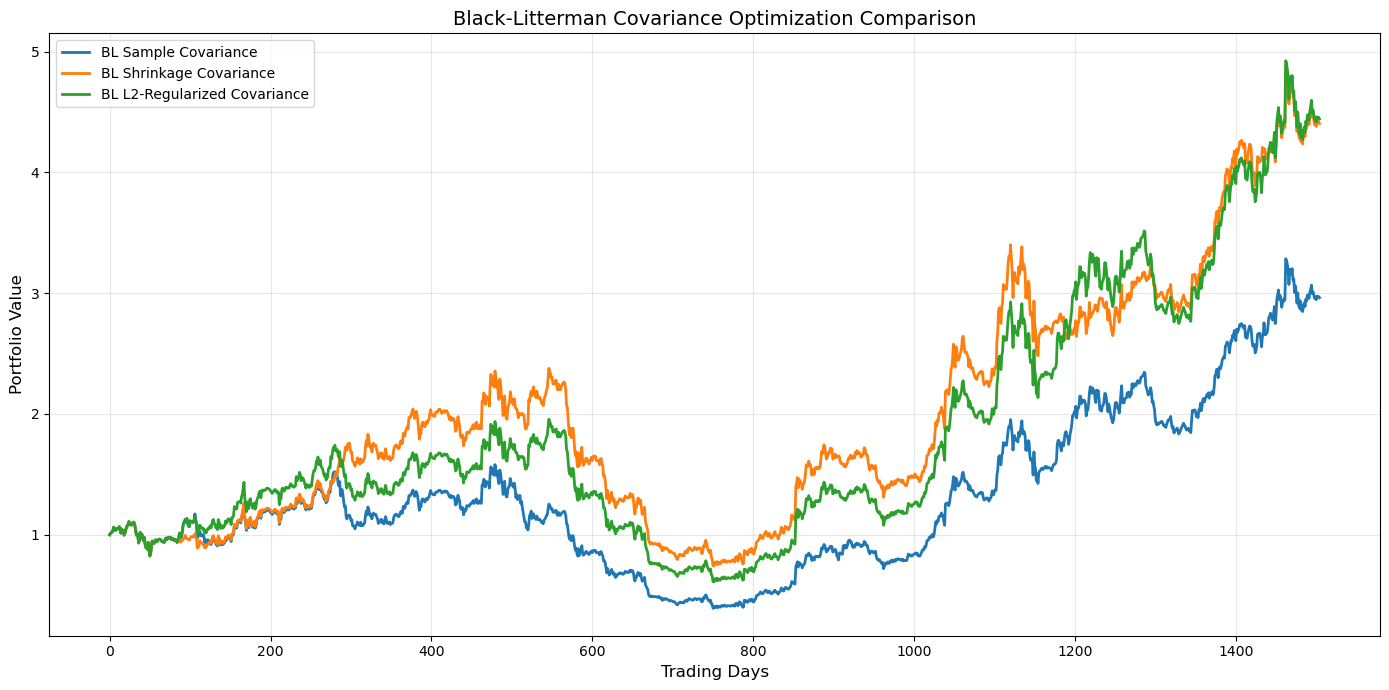

Best strategy: BL Shrinkage Covariance


,BL Sample Covariance,BL Shrinkage Covariance,BL L2-Regularized Covariance
Annual Return,0.1996,0.2820,0.2838
Annual Volatility,0.4173,0.3962,0.4074
Sharpe Ratio,0.4304,0.6613,0.6475
Max Drawdown,-0.7528,-0.6885,-0.6885
Turnover,0.6479,0.7183,0.6716
VaR(95%),-0.0398,-0.0368,-0.0376


In [8]:
metrics, results, best_strategy = run_covariance_experiment(
    etf_returns_path='etf_returns.csv',
    stock_returns_path='stock_returns.csv',
    train_window=252 * 5,
    rebalance_freq=21,
    tau=0.05,
    shrinkage_strength=0.35,
    l2_penalty=0.10,
    plot=True,
)

print('Best strategy:', best_strategy)
metrics.round(4)

## 4. Save Metrics

Optional: export the comparison table for your report.

In [9]:
metrics.round(6).to_csv('covariance_backtest_metrics.csv')
pd.DataFrame({'best_strategy': [best_strategy]}).to_csv('covariance_backtest_best_strategy.csv', index=False)
print('Saved: covariance_backtest_metrics.csv')
print('Saved: covariance_backtest_best_strategy.csv')

Saved: covariance_backtest_metrics.csv
Saved: covariance_backtest_best_strategy.csv


## 5. Inspect Final Weights

Look at the latest portfolio weights from each covariance method.

In [10]:
latest_weights = pd.DataFrame(
    {
        strategy: result['weights'][-1]
        for strategy, result in results.items()
    },
    index=combined_returns.columns,
)

latest_weights.round(4)

,BL Sample Covariance,BL Shrinkage Covariance,BL L2-Regularized Covariance
EEM,-0.0,0.0,0.0
EFA,-0.0,0.0,0.0
IWM,-0.0,0.0,0.0
QQQ,-0.0,0.0,-0.0
SPY,-0.0,0.0,0.0
TLT,0.0,-0.0,-0.0
VNQ,-0.0,0.0,0.0
XLE,-0.0,0.0,0.0
XLK,-0.0,0.0,-0.0
XLV,-0.0,0.0,0.0
